In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('NKE.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,1/3/2000,4.471374,4.604934,4.436532,4.581707,8014400
1,1/4/2000,4.227483,4.395886,4.215869,4.366851,9810400
2,1/5/2000,4.471374,4.494601,4.250708,4.250708,6542400
3,1/6/2000,4.448146,4.448146,4.326200,4.448146,4891200
4,1/7/2000,4.448146,4.459760,4.366849,4.430726,3993600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6559 non-null   object 
 1   Close   6559 non-null   float64
 2   High    6559 non-null   float64
 3   Low     6559 non-null   float64
 4   Open    6559 non-null   float64
 5   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 307.6+ KB


In [4]:
df.describe()

,Close,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,42.201151,42.637645,41.762623,42.200481,1.066901e+07
std,39.940264,40.360158,39.533845,39.956246,7.294436e+06
min,2.467967,2.514423,2.398283,2.502809,1.821900e+06
25%,8.364538,8.445401,8.305094,8.366846,6.505200e+06
50%,23.116028,23.278135,22.891102,23.082078,8.921700e+06
75%,70.471672,71.534835,69.971637,70.638438,1.264680e+07
max,166.246811,167.735935,164.364352,165.160424,1.299670e+08


In [5]:
df["Date"]=pd.to_datetime(df["Date"])
df.set_index("Date",inplace=True)

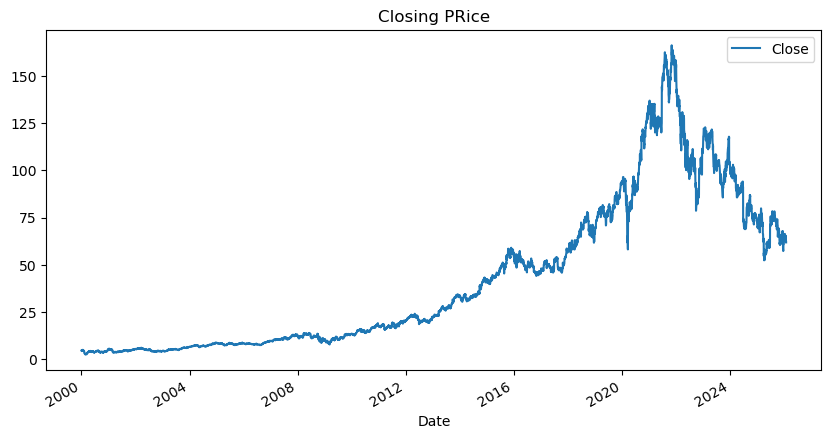

In [7]:
df[["Close"]].plot(figsize=(10,5))
plt.title("Closing PRice")
plt.show()

<Axes: >

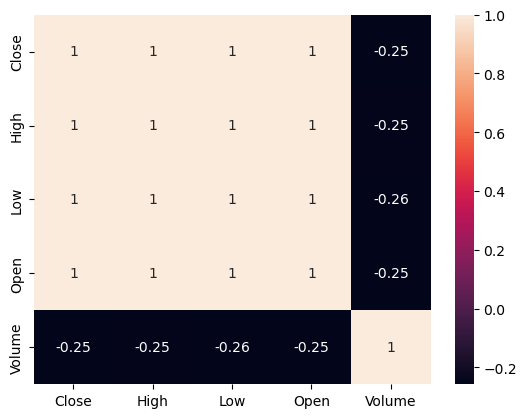

In [8]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='Date'>

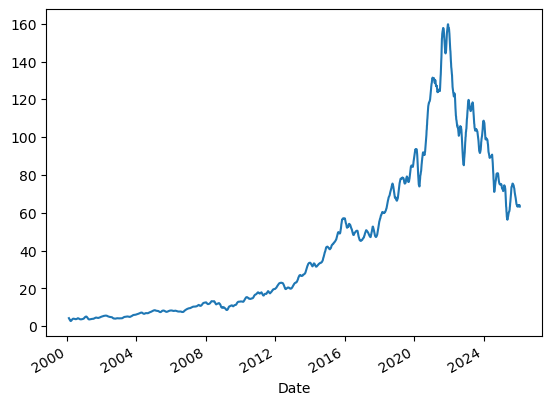

In [9]:
df["Close"].rolling(window=30).mean().plot()

<Axes: >

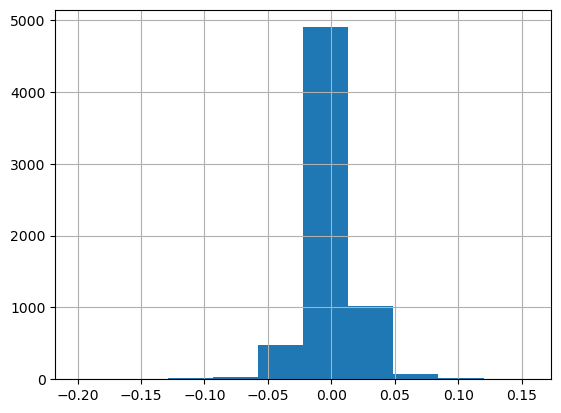

In [10]:
df["Close"].pct_change().hist()

In [ ]:
# pct_change=(current-previous)/previous

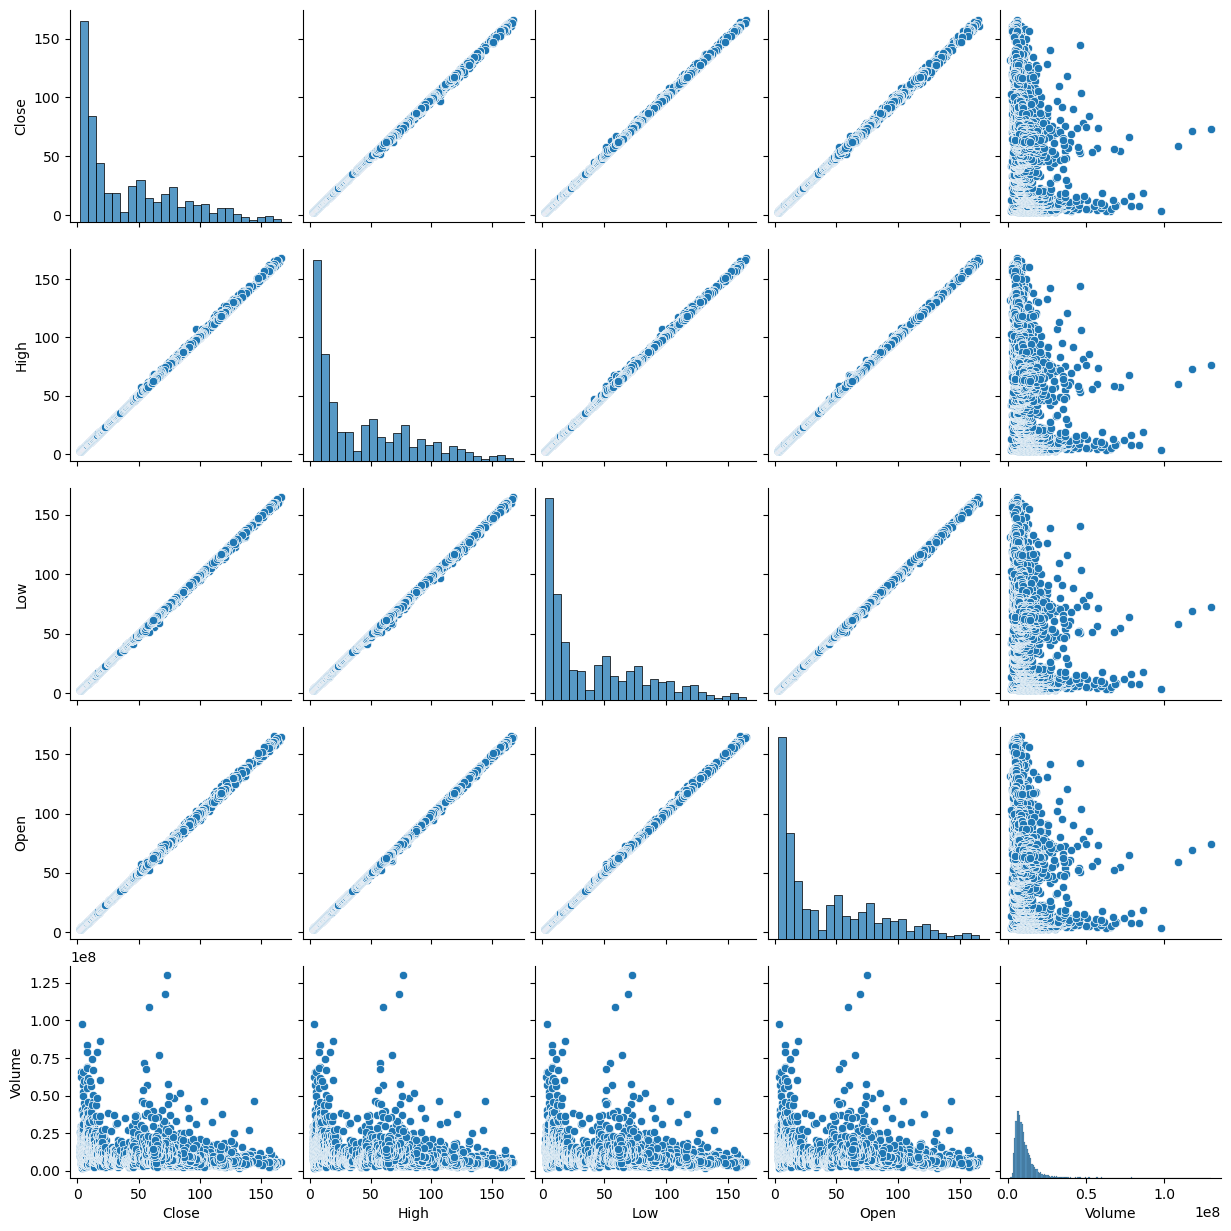

In [11]:
sns.pairplot(df)

In [16]:
df["MA50"]=df["Close"].rolling(50).mean()


In [17]:
df["MA200"]=df["Close"].rolling(200).mean()

<Axes: xlabel='Date'>

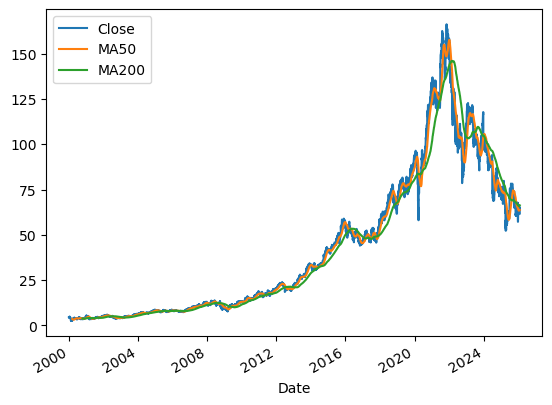

In [19]:
df[["Close","MA50","MA200"]].plot()

In [20]:
df["Daily Return"]=df["Close"].pct_change()

<Axes: xlabel='Daily Return', ylabel='Count'>

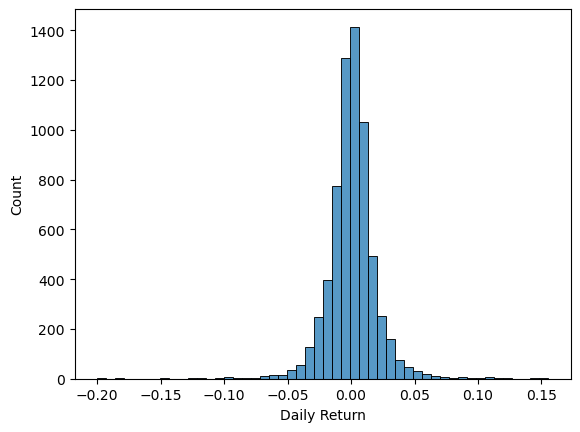

In [22]:
sns.histplot(df["Daily Return"],bins=50)

<Axes: xlabel='Date'>

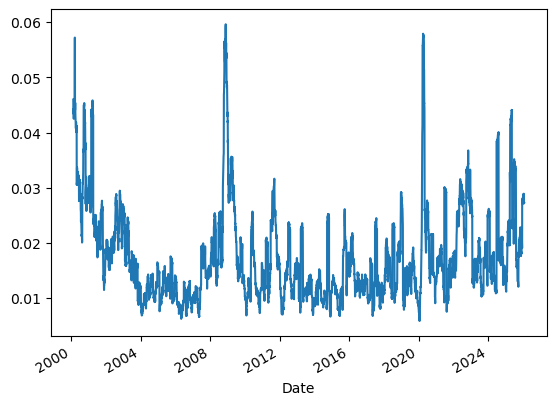

In [24]:
df["Volatility"]=df["Daily Return"].rolling(30).std()
df["Volatility"].plot()

<Axes: xlabel='Date'>

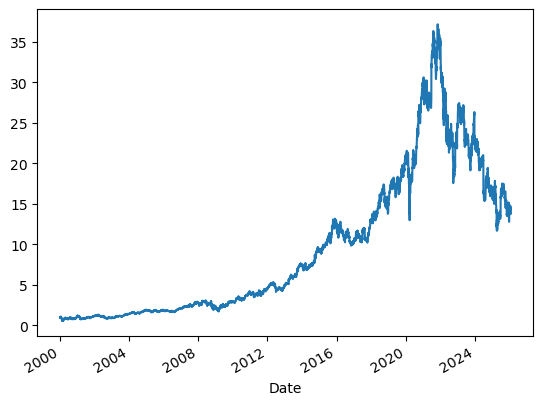

In [25]:
df["Cumulative Return"]=(1+df["Daily Return"]).cumprod()
df["Cumulative Return"].plot()

In [ ]:
# 0.01+1=101%